# Dark Matters ABM
## Structured Analysis Workbook

This notebook turns either a single exported simulation CSV or a batch experiment CSV into a readable analysis report.
It is designed to feel like a guided workbook rather than a raw script, with narrative framing, tables, and one figure per code cell.

### What this workbook helps you do
- inspect the scenario configuration for a selected run
- summarize the trajectory of a selected run
- identify formal tipping points
- compare short-term extraction to long-term sustainability
- when batch results are loaded, review batch coverage and aggregated end-state summaries before drilling into one run


## Contents

1. Setup and data loading
2. Theory and metric guide
3. Batch overview and run selection
4. Scenario and descriptive summaries for the selected run
5. Formal tipping-point review
6. Narrative interpretation
7. One-figure-at-a-time diagnostic plots
8. Discussion prompts for writing and presentation

## Suggested workflow

Run the notebook from top to bottom. If you are using Google Colab, leave `CSV_PATH = None` and upload the exported file when prompted. If you are running locally, set `CSV_PATH` to the file you want to analyze.

If you load a batch CSV, the notebook will auto-detect it, show batch-level summary tables, and then analyze one selected trajectory. Override `BATCH_RUN_ID` and `BATCH_ITERATION` in the config cell if you want a different run.


In [60]:
from __future__ import annotations

from pathlib import Path
from textwrap import dedent
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.facecolor": "#fcfcfd",
        "figure.facecolor": "white",
        "axes.edgecolor": "#cbd5e1",
        "grid.color": "#cbd5e1",
        "grid.alpha": 0.35,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


## Load A CSV Export

The notebook supports both single-run exports and batch experiment exports.

The loading cell supports two environments:

- local/Jupyter: set `CSV_PATH` to a file path
- Google Colab: leave `CSV_PATH = None` and run the cell to upload a file

Optional batch controls:

- `BATCH_RUN_ID`: choose a specific batch `RunId`
- `BATCH_ITERATION`: choose a specific iteration within that run


In [61]:
CSV_PATH = "results/simulation-most-realistic-so-far/simulation-5110c31f-2569-4f8d-98f5-ed4f55d497e1.csv"

# Optional when loading backend/results/batch_results.csv.
# Leave as None to analyze the first available trajectory.
BATCH_RUN_ID = None
BATCH_ITERATION = None


def in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False


def load_csv_from_colab_upload() -> pd.DataFrame:
    from google.colab import files

    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file was uploaded.")
    first_name = next(iter(uploaded))
    return pd.read_csv(first_name)


def load_dataframe(csv_path: str | Path | None) -> pd.DataFrame:
    if csv_path is None:
        if in_colab():
            return load_csv_from_colab_upload()
        raise ValueError("Set CSV_PATH when running outside Google Colab.")
    return pd.read_csv(csv_path)

## Theory And Metric Guide

### What the exported CSV represents
- In a single-run export, each row corresponds to one simulation step for one simulation.
- In a batch export, each row corresponds to one simulation step inside one `RunId` and `iteration` trajectory.

This notebook always reduces the data to one selected trajectory for the run-level narrative, tables, and plots below. When batch data is loaded, it also shows batch-level overview tables before drilling into the selected trajectory.

### Formal tipping-point detection
A tipping point is only recorded when a threshold is sustained for three consecutive steps.

The current rules are:

- Trust Collapse: mean trust is at or below `0.50`
- Social Contagion: negative WOM is at or above `0.22`
- Churn Cascade: cumulative churn is at or above `0.35`
- Extractive Divergence: revenue gap exceeds `20%` of short-term revenue while cumulative churn is at or above `0.15`

### Core metrics

- `active_users`: users still active on the platform
- `mean_trust`: average trust among active users
- `mean_harm`: average accumulated harm among active users
- `churn_rate`: step-level increase in cumulative churn
- `cumulative_churn`: share of users who have churned
- `negative_wom_rate`: average negative word-of-mouth among active users
- `platform_reputation`: platform reputation on 0-100 scale
- `reputation`: platform reputation proxy (0-1 scale)
- `short_term_revenue`: accumulated short-run revenue proxy
- `long_term_revenue`: revenue proxy discounted by churn

### Economics metrics (v1.3.0)

- `step_revenue`: per-step total revenue (subscription + DP extraction), discounted by reputation
- `step_costs`: per-step costs (churn replacement + support + WOM damage)
- `step_profit`: per-step profit (revenue - costs)
- `cumulative_revenue`: running total of actual revenue (starts from initial platform traction)
- `cumulative_costs`: running total of costs
- `net_value`: cumulative revenue minus cumulative costs
- `cumulative_projected_revenue`: projected revenue if no dark patterns were used (all users retained, full reputation)
- `opportunity_cost`: cumulative projected revenue minus actual — the price of dark patterns

In [62]:
PARAMETER_COLUMNS = [
    "adaptive_platform",
    "alpha_exposure_to_trust",
    "avg_degree",
    "beta_support_recovery",
    "complaint_propensity_mean",
    "complaint_propensity_sd",
    "customer_support_quality",
    "dark_pattern_intensity",
    "delta_exposure_to_harm",
    "digital_literacy_mean",
    "digital_literacy_sd",
    "drip_pricing_exposure_prob",
    "drip_pricing_severity",
    "forced_trial_exposure_prob",
    "forced_trial_severity",
    "gamma_social_trust_loss",
    "hard_cancel_exposure_prob",
    "hard_cancel_severity",
    "manipulation_sensitivity_mean",
    "manipulation_sensitivity_sd",
    "max_steps",
    "network_type",
    "num_users",
    "pattern_drip_pricing",
    "pattern_forced_trial",
    "pattern_hard_cancel",
    "review_visibility",
    "rewire_prob",
    "seed",
    "social_activity_mean",
    "social_activity_sd",
    "social_influence_strength",
    "switching_cost_mean",
    "switching_cost_sd",
    "theta0",
    "theta_harm",
    "theta_social",
    "theta_switching_cost",
    "theta_trust",
    "trust_baseline_mean",
    "trust_baseline_sd",
]

METRIC_COLUMNS = [
    "active_users",
    "any_tipping_point_triggered",
    "churn_rate",
    "cumulative_churn",
    "cumulative_costs",
    "cumulative_projected_revenue",
    "cumulative_revenue",
    "extractive_divergence_step",
    "extractive_divergence_triggered",
    "first_tipping_point_step",
    "long_term_revenue",
    "mean_harm",
    "mean_trust",
    "negative_wom_rate",
    "net_value",
    "opportunity_cost",
    "platform_reputation",
    "reputation",
    "short_term_revenue",
    "social_contagion_step",
    "social_contagion_triggered",
    "step",
    "step_costs",
    "step_profit",
    "step_revenue",
    "tipping_points_triggered_count",
    "trust_collapse_step",
    "trust_collapse_triggered",
    "churn_cascade_step",
    "churn_cascade_triggered",
]

TIPPING_POINT_SPECS = {
    "trust_collapse": {
        "trigger_column": "trust_collapse_triggered",
        "step_column": "trust_collapse_step",
        "label": "Trust Collapse",
        "color": "#2563eb",
    },
    "social_contagion": {
        "trigger_column": "social_contagion_triggered",
        "step_column": "social_contagion_step",
        "label": "Social Contagion",
        "color": "#059669",
    },
    "churn_cascade": {
        "trigger_column": "churn_cascade_triggered",
        "step_column": "churn_cascade_step",
        "label": "Churn Cascade",
        "color": "#dc2626",
    },
    "extractive_divergence": {
        "trigger_column": "extractive_divergence_triggered",
        "step_column": "extractive_divergence_step",
        "label": "Extractive Divergence",
        "color": "#d97706",
    },
}

CORRELATION_COLUMNS = [
    "active_users",
    "active_share",
    "churn_rate",
    "cumulative_churn",
    "long_term_revenue",
    "mean_harm",
    "mean_trust",
    "negative_wom_rate",
    "net_value",
    "opportunity_cost",
    "platform_reputation",
    "reputation",
    "revenue_gap",
    "short_term_revenue",
    "step_profit",
    "step_revenue",
    "trust_loss_from_baseline",
]


def show_md(text: str) -> None:
    display(Markdown(text))


def normalize_dataframe_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {}
    if "Step" in df.columns and "step" not in df.columns:
        rename_map["Step"] = "step"
    if "RunId" in df.columns and "run_id" not in df.columns:
        rename_map["RunId"] = "run_id"
    return df.rename(columns=rename_map)


def detect_data_mode(df: pd.DataFrame) -> str:
    columns = set(df.columns)
    if {"run_id", "iteration", "step"}.issubset(columns):
        return "batch_run"
    if "simulation_id" in columns or "step" in columns:
        return "single_run"
    return "unknown"


def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = normalize_dataframe_columns(df.copy())

    for column in cleaned.columns:
        if cleaned[column].dtype == object:
            non_null = cleaned[column].dropna().astype(str).str.lower()
            if not non_null.empty and non_null.isin({"true", "false"}).all():
                cleaned[column] = cleaned[column].astype(str).str.lower().map({"true": True, "false": False})

    numeric_columns = sorted({*METRIC_COLUMNS, "step", "run_id", "iteration", "seed"})
    for column in numeric_columns:
        if column in cleaned.columns:
            cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce")

    for column in ["run_id", "iteration", "step"]:
        if column in cleaned.columns:
            series = cleaned[column].dropna()
            if not series.empty and (series % 1 == 0).all():
                cleaned[column] = cleaned[column].astype("Int64")

    mode = detect_data_mode(cleaned)
    if mode == "batch_run":
        cleaned = cleaned.sort_values(["run_id", "iteration", "step"]).reset_index(drop=True)
    elif "step" in cleaned.columns:
        cleaned = cleaned.sort_values("step").reset_index(drop=True)

    if "num_users" in cleaned.columns and "active_users" in cleaned.columns:
        cleaned["active_share"] = cleaned["active_users"] / cleaned["num_users"]

    if "mean_trust" in cleaned.columns:
        if {"run_id", "iteration"}.issubset(cleaned.columns):
            baseline = cleaned.groupby(["run_id", "iteration"], dropna=False)["mean_trust"].transform("first")
            cleaned["trust_loss_from_baseline"] = baseline - cleaned["mean_trust"]
        elif "simulation_id" in cleaned.columns:
            baseline = cleaned.groupby("simulation_id", dropna=False)["mean_trust"].transform("first")
            cleaned["trust_loss_from_baseline"] = baseline - cleaned["mean_trust"]
        else:
            baseline = float(cleaned["mean_trust"].iloc[0])
            cleaned["trust_loss_from_baseline"] = baseline - cleaned["mean_trust"]

    if "short_term_revenue" in cleaned.columns and "long_term_revenue" in cleaned.columns:
        cleaned["revenue_gap"] = cleaned["short_term_revenue"] - cleaned["long_term_revenue"]

    return cleaned


def tipping_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for spec in TIPPING_POINT_SPECS.values():
        trigger_column = spec["trigger_column"]
        step_column = spec["step_column"]
        if trigger_column not in df.columns or step_column not in df.columns:
            continue

        triggered = bool(df[trigger_column].fillna(0).max() >= 1)
        raw_step = df.loc[df[step_column] >= 0, step_column]
        trigger_step = None if raw_step.empty else int(raw_step.iloc[0])
        rows.append(
            {
                "tipping_point": spec["label"],
                "triggered": triggered,
                "trigger_step": trigger_step,
            }
        )
    return pd.DataFrame(rows)


def parameter_summary(df: pd.DataFrame) -> pd.DataFrame:
    available = [column for column in PARAMETER_COLUMNS if column in df.columns]
    if not available:
        return pd.DataFrame(columns=["parameter", "value"])
    row = df.iloc[0][available]
    return pd.DataFrame({"parameter": available, "value": row.values})


def metric_summary(df: pd.DataFrame) -> pd.DataFrame:
    available = [column for column in METRIC_COLUMNS if column in df.columns]
    if not available:
        return pd.DataFrame()
    summary = pd.DataFrame(
        {
            "start": df[available].iloc[0],
            "end": df[available].iloc[-1],
            "min": df[available].min(),
            "max": df[available].max(),
            "mean": df[available].mean(),
        }
    )
    return summary.round(4)


def triggered_tipping_labels(df: pd.DataFrame) -> list[str]:
    summary = tipping_summary(df)
    if summary.empty:
        return []
    return summary.loc[summary["triggered"], "tipping_point"].astype(str).tolist()


def final_rows_by_trajectory(df: pd.DataFrame) -> pd.DataFrame:
    if detect_data_mode(df) != "batch_run":
        return df.tail(1).reset_index(drop=True)
    return (
        df.sort_values(["run_id", "iteration", "step"])
        .groupby(["run_id", "iteration"], dropna=False, sort=True)
        .tail(1)
        .reset_index(drop=True)
    )


def varying_parameter_columns(df: pd.DataFrame) -> list[str]:
    return [
        column
        for column in PARAMETER_COLUMNS
        if column in df.columns and df[column].nunique(dropna=False) > 1
    ]


def batch_overview(df: pd.DataFrame) -> pd.DataFrame:
    if detect_data_mode(df) != "batch_run":
        return pd.DataFrame()

    trajectories = (
        df[["run_id", "iteration", "step"]]
        .groupby(["run_id", "iteration"], dropna=False)
        .agg(step_min=("step", "min"), step_max=("step", "max"), row_count=("step", "count"))
        .reset_index()
    )
    finals = final_rows_by_trajectory(df)
    varying = varying_parameter_columns(finals)
    combo_count = finals[varying].drop_duplicates().shape[0] if varying else 1

    rows = [
        {"metric": "dataset_mode", "value": "batch_run"},
        {"metric": "rows_loaded", "value": int(len(df))},
        {"metric": "trajectory_count", "value": int(len(trajectories))},
        {"metric": "unique_run_ids", "value": int(trajectories["run_id"].nunique(dropna=True))},
        {"metric": "parameter_combinations", "value": int(combo_count)},
        {"metric": "steps_per_trajectory_min", "value": int(trajectories["row_count"].min())},
        {"metric": "steps_per_trajectory_max", "value": int(trajectories["row_count"].max())},
    ]
    if varying:
        rows.append({"metric": "varying_parameters", "value": ", ".join(varying)})
    return pd.DataFrame(rows)


def batch_end_state_summary(df: pd.DataFrame) -> pd.DataFrame:
    if detect_data_mode(df) != "batch_run":
        return pd.DataFrame()

    finals = final_rows_by_trajectory(df)
    columns = [
        column
        for column in [
            "mean_trust",
            "cumulative_churn",
            "mean_harm",
            "negative_wom_rate",
            "short_term_revenue",
            "long_term_revenue",
            "net_value",
            "opportunity_cost",
            "any_tipping_point_triggered",
            "tipping_points_triggered_count",
            "first_tipping_point_step",
        ]
        if column in finals.columns
    ]
    if not columns:
        return pd.DataFrame()
    return finals[columns].agg(["mean", "std", "min", "max"]).T.round(4)


def select_analysis_run(
    df: pd.DataFrame,
    run_id: int | None = None,
    iteration: int | None = None,
) -> tuple[pd.DataFrame, dict]:
    mode = detect_data_mode(df)
    context = {
        "data_mode": mode,
        "trajectory_count": 1,
        "notes": [],
    }

    if mode != "batch_run":
        if "simulation_id" in df.columns:
            simulation_ids = df["simulation_id"].dropna().astype(str).unique().tolist()
            context["simulation_ids_found"] = len(simulation_ids)
            if simulation_ids:
                context["selected_label"] = simulation_ids[0]
        return df.copy().reset_index(drop=True), context

    trajectories = (
        df[["run_id", "iteration"]]
        .drop_duplicates()
        .sort_values(["run_id", "iteration"])
        .reset_index(drop=True)
    )
    if trajectories.empty:
        raise ValueError("No batch trajectories were found in the CSV.")

    context["trajectory_count"] = int(len(trajectories))
    context["varying_parameters"] = varying_parameter_columns(final_rows_by_trajectory(df))

    available_run_ids = set(trajectories["run_id"].dropna().tolist())
    selected_run_id = run_id
    if selected_run_id is not None and selected_run_id not in available_run_ids:
        context["notes"].append(
            f"Requested BATCH_RUN_ID={run_id} was not found. Using the first available run instead."
        )
        selected_run_id = None

    if selected_run_id is None:
        if iteration is not None:
            matching = trajectories.loc[trajectories["iteration"] == iteration, "run_id"]
            selected_run_id = matching.iloc[0] if not matching.empty else trajectories.iloc[0]["run_id"]
        else:
            selected_run_id = trajectories.iloc[0]["run_id"]

    run_subset = trajectories.loc[trajectories["run_id"] == selected_run_id].reset_index(drop=True)
    selected_iteration = iteration
    available_iterations = set(run_subset["iteration"].dropna().tolist())
    if selected_iteration is not None and selected_iteration not in available_iterations:
        context["notes"].append(
            f"Requested BATCH_ITERATION={iteration} was not found for run_id={selected_run_id}. Using the first available iteration instead."
        )
        selected_iteration = None

    if selected_iteration is None:
        selected_iteration = run_subset.iloc[0]["iteration"]

    selected = df.loc[
        (df["run_id"] == selected_run_id) & (df["iteration"] == selected_iteration)
    ].copy()
    selected = selected.sort_values("step").reset_index(drop=True)

    context["selected_run_id"] = int(selected_run_id)
    context["selected_iteration"] = int(selected_iteration)
    context["selected_label"] = f"run_id={int(selected_run_id)}, iteration={int(selected_iteration)}"
    return selected, context


def narrative_summary(df: pd.DataFrame) -> str:
    final = df.iloc[-1]
    start = df.iloc[0]

    trust_change = float(final["mean_trust"] - start["mean_trust"]) if "mean_trust" in df.columns else 0.0
    churn_end = float(final["cumulative_churn"]) if "cumulative_churn" in df.columns else 0.0
    wom_peak = float(df["negative_wom_rate"].max()) if "negative_wom_rate" in df.columns else 0.0
    harm_end = float(final["mean_harm"]) if "mean_harm" in df.columns else 0.0
    revenue_gap_end = float(final["revenue_gap"]) if "revenue_gap" in df.columns else 0.0
    triggered = triggered_tipping_labels(df)

    opp_cost_end = float(final["opportunity_cost"]) if "opportunity_cost" in df.columns else 0.0
    net_value_end = float(final["net_value"]) if "net_value" in df.columns else 0.0

    if trust_change <= -0.15:
        trust_read = "The run shows a substantial erosion of trust."
    elif trust_change <= -0.05:
        trust_read = "The run shows a moderate decline in trust."
    else:
        trust_read = "Trust remains comparatively stable over the run."

    if churn_end >= 0.5:
        churn_read = "Cumulative churn ends at a high level, suggesting deep long-run user loss."
    elif churn_end >= 0.2:
        churn_read = "Cumulative churn is meaningful and should be treated as a warning signal."
    else:
        churn_read = "Cumulative churn remains comparatively contained."

    if revenue_gap_end > 0:
        revenue_read = (
            "Short-term revenue exceeds long-term revenue at the end of the run, "
            "which is consistent with extraction outpacing durable value."
        )
    else:
        revenue_read = (
            "Short-term and long-term revenue remain relatively aligned, "
            "which suggests less divergence between extraction and sustainability."
        )

    if opp_cost_end > 0:
        opp_read = (
            f"The cumulative opportunity cost of dark patterns is **{opp_cost_end:,.0f}**, "
            f"representing revenue lost due to churn and reputation damage versus a no-DP baseline. "
            f"Final net value stands at **{net_value_end:,.0f}**."
        )
    else:
        opp_read = ""

    if triggered:
        tipping_read = "The formal tipping detector was activated for: " + ", ".join(f"**{name}**" for name in triggered) + "."
    else:
        tipping_read = "No formal tipping point is triggered under the current detection rules."

    return dedent(
        f"""
        ## Automated Interpretation

        {trust_read}

        {churn_read}

        End-of-run mean harm is **{harm_end:.3f}** and the peak negative WOM rate is **{wom_peak:.3f}**.

        {revenue_read}

        {opp_read}

        {tipping_read}
        """
    ).strip()


def add_tipping_markers(df: pd.DataFrame, ax) -> None:
    used_labels = set()
    for spec in TIPPING_POINT_SPECS.values():
        step_column = spec["step_column"]
        if step_column not in df.columns:
            continue
        valid_steps = df.loc[df[step_column] >= 0, step_column]
        if valid_steps.empty:
            continue
        trigger_step = int(valid_steps.iloc[0])
        label = spec["label"]
        ax.axvline(
            trigger_step,
            color=spec["color"],
            linestyle="--",
            linewidth=1.6,
            alpha=0.75,
            label=label if label not in used_labels else None,
        )
        used_labels.add(label)


def finish_axis(ax, *, xlabel: str, ylabel: str, title: str) -> None:
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.25)
    sns.despine(ax=ax)


def line_chart(
    df: pd.DataFrame,
    columns: Iterable[str],
    title: str,
    ylabel: str,
    colors: list[str] | None = None,
    ylim: tuple[float, float] | None = None,
    figsize: tuple[int, int] = (12, 5),
    styles: list[str] | None = None,
) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    for idx, column in enumerate(columns):
        if column not in df.columns:
            continue
        color = None if colors is None else colors[idx]
        style = "-" if styles is None else styles[idx]
        ax.plot(
            df["step"],
            df[column],
            linewidth=2.4,
            label=column,
            color=color,
            linestyle=style,
            marker="o",
            markersize=3,
            alpha=0.95,
        )
    if ylim is not None:
        ax.set_ylim(*ylim)
    add_tipping_markers(df, ax)
    finish_axis(ax, xlabel="Step", ylabel=ylabel, title=title)
    ax.legend(fontsize=9, frameon=True)
    plt.tight_layout()
    plt.show()

## Load, Clean, And Inspect The Data

This cell loads the CSV, normalizes single-run versus batch-run column names, cleans booleans and numeric columns, derives helper variables such as `active_share`, `trust_loss_from_baseline`, and `revenue_gap`, and then selects one trajectory for the run-level analysis below.

If a batch CSV is loaded, the cell also shows batch-wide overview tables before previewing the selected trajectory.


In [63]:
raw_df = load_dataframe(CSV_PATH)
dataset_df = clean_dataframe(raw_df)
DATA_MODE = detect_data_mode(dataset_df)
df, ANALYSIS_CONTEXT = select_analysis_run(dataset_df, BATCH_RUN_ID, BATCH_ITERATION)
BATCH_OVERVIEW = batch_overview(dataset_df)
BATCH_END_STATE_SUMMARY = batch_end_state_summary(dataset_df)

if DATA_MODE == "batch_run":
    varying_parameters = ANALYSIS_CONTEXT.get("varying_parameters", [])
    varying_text = ", ".join(varying_parameters) if varying_parameters else "none detected"
    show_md(
        dedent(
            f"""
            ## Loaded batch experiment data

            - Rows loaded: **{len(dataset_df)}**
            - Trajectories found: **{ANALYSIS_CONTEXT['trajectory_count']}**
            - Selected trajectory for detailed analysis: **{ANALYSIS_CONTEXT['selected_label']}**
            - Varying parameters across the batch: **{varying_text}**

            The tables below summarize the full batch. The remaining sections of the notebook analyze the selected trajectory.
            """
        ).strip()
    )
    if ANALYSIS_CONTEXT["notes"]:
        show_md("\n".join(f"- {note}" for note in ANALYSIS_CONTEXT["notes"]))
    display(BATCH_OVERVIEW)
    if not BATCH_END_STATE_SUMMARY.empty:
        show_md("### Batch end-state summary")
        display(BATCH_END_STATE_SUMMARY)
    show_md("### Selected trajectory preview")
    df.head()
else:
    if "simulation_id" in dataset_df.columns:
        simulation_ids = dataset_df["simulation_id"].dropna().astype(str).unique().tolist()
        selected_label = simulation_ids[0] if simulation_ids else "n/a"
        show_md(
            f"## Loaded simulation data\n\n"
            f"- Rows: **{len(dataset_df)}**\n"
            f"- Simulation IDs found: **{len(simulation_ids)}**\n"
            f"- Selected run for analysis: **{selected_label}**"
        )
    else:
        show_md(f"## Loaded simulation data\n\n- Rows: **{len(dataset_df)}**")
    df.head()


## Loaded simulation data

- Rows: **312**
- Simulation IDs found: **1**
- Selected run for analysis: **5110c31f-2569-4f8d-98f5-ed4f55d497e1**

## Scenario Parameters

This table captures the configuration of the selected run. Because the export repeats these fields in every row, we only need the first row to summarize the scenario.


In [64]:
parameter_summary(df)


,parameter,value
0,adaptive_platform,False
1,avg_degree,8
2,customer_support_quality,0.3
3,dark_pattern_intensity,0.4
4,max_steps,312
5,network_type,small_world
6,num_users,500
7,pattern_drip_pricing,True
8,pattern_forced_trial,True
9,pattern_hard_cancel,True


## Descriptive Summary Of The Selected Run

The table below compares the start, end, minimum, maximum, and mean of the main simulation metrics across the selected trajectory.


In [65]:
metric_summary(df)


,start,end,min,max,mean
active_users,500.0,180.0,180.0,500.0,329.9327
any_tipping_point_triggered,0.0,1.0,0.0,1.0,0.7468
churn_rate,0.0,0.002,0.0,0.01,0.0021
cumulative_churn,0.0,0.64,0.0,0.64,0.3401
cumulative_costs,0.0,15924.84,0.0,15924.84,9539.1518
cumulative_projected_revenue,10000.0,638680.13,10000.0,638680.13,324340.065
cumulative_revenue,10000.0,301583.6743,10000.0,301583.6743,234977.6893
extractive_divergence_step,-1.0,85.0,-1.0,85.0,61.5705
extractive_divergence_triggered,0.0,1.0,0.0,1.0,0.7276
first_tipping_point_step,-1.0,79.0,-1.0,79.0,58.7436


## Formal Tipping-Point Summary

This table shows whether each tipping point was triggered and, if so, the first step at which it was confirmed for the selected trajectory.


In [66]:
tipping_summary(df)


,tipping_point,triggered,trigger_step
0,Trust Collapse,True,79.0
1,Social Contagion,False,NaN
2,Churn Cascade,True,152.0
3,Extractive Divergence,True,85.0


## Automated Interpretation

This text block converts the end-state of the selected trajectory into a short narrative summary. It is not a replacement for interpretation, but it gives a fast read on whether the scenario looks comparatively stable, warning-heavy, or clearly extractive.


In [67]:
show_md(narrative_summary(df))


## Automated Interpretation

Trust remains comparatively stable over the run.

Cumulative churn ends at a high level, suggesting deep long-run user loss.

End-of-run mean harm is **0.256** and the peak negative WOM rate is **0.170**.

Short-term revenue exceeds long-term revenue at the end of the run, which is consistent with extraction outpacing durable value.

The cumulative opportunity cost of dark patterns is **337,096**, representing revenue lost due to churn and reputation damage versus a no-DP baseline. Final net value stands at **285,659**.

The formal tipping detector was activated for: **Trust Collapse**, **Churn Cascade**, **Extractive Divergence**.

## Plot 1: Trust And Reputation

This figure shows whether users continue to trust the platform and whether the platform's aggregate standing remains stable over time. A strong joint decline suggests that manipulation is undermining both user sentiment and system legitimacy.


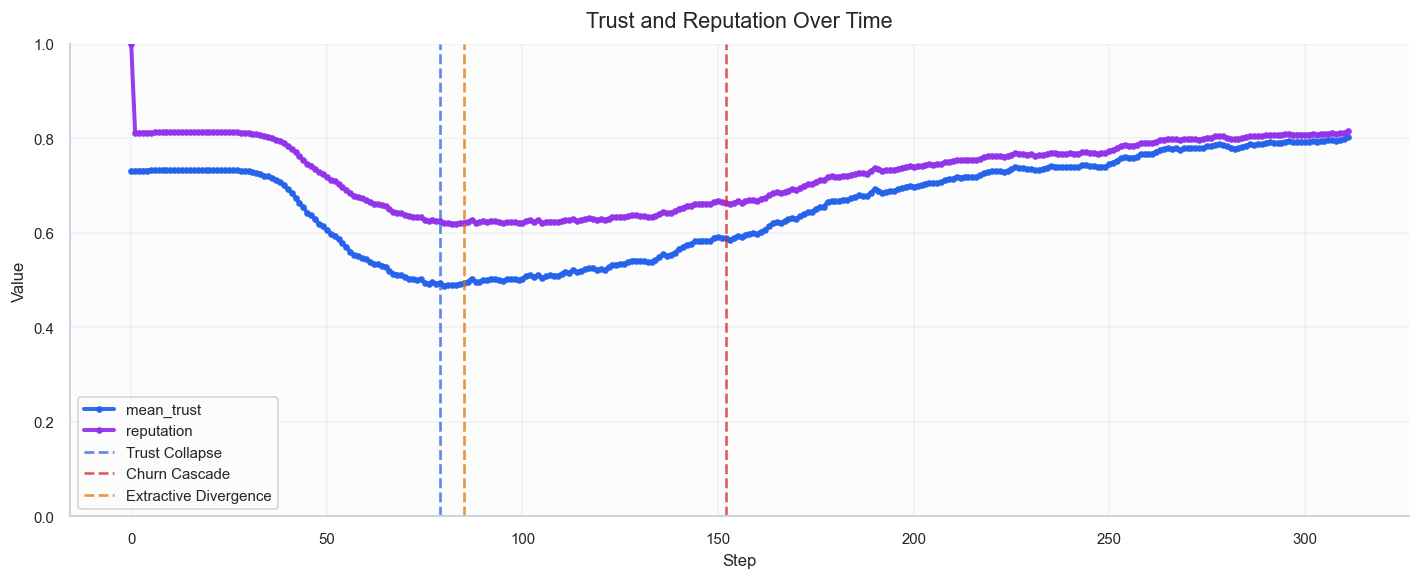

In [68]:
line_chart(
    df,
    ["mean_trust", "reputation"],
    "Trust and Reputation Over Time",
    "Value",
    colors=["#2563eb", "#9333ea"],
    ylim=(0, 1),
)


## Plot 2: Churn And Negative WOM

This figure helps identify diffusion and exit dynamics. If churn and negative word-of-mouth rise together, the model is showing a social pathway through which bad experience spreads and then converts into user loss.


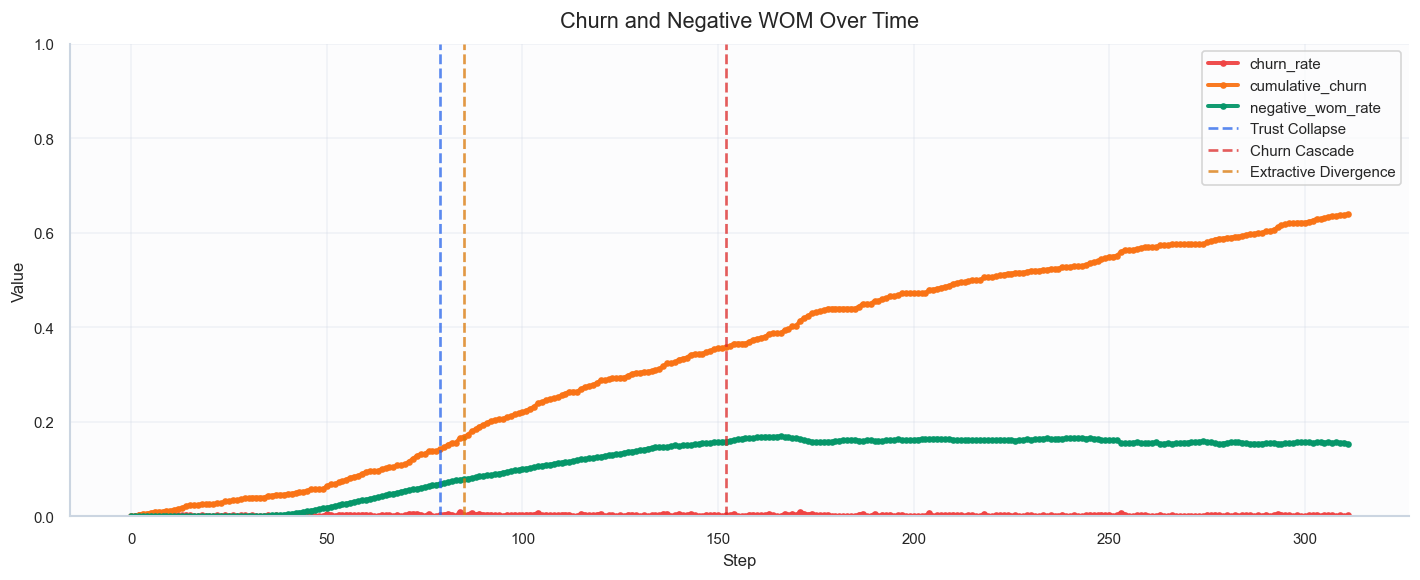

In [69]:
line_chart(
    df,
    ["churn_rate", "cumulative_churn", "negative_wom_rate"],
    "Churn and Negative WOM Over Time",
    "Value",
    colors=["#ef4444", "#f97316", "#059669"],
    ylim=(0, 1),
)


## Plot 3: Revenue Dynamics

This is the key extraction-versus-sustainability plot. The main question is whether short-term revenue keeps rising while long-term revenue falls behind, indicating divergence between immediate gains and durable platform value.


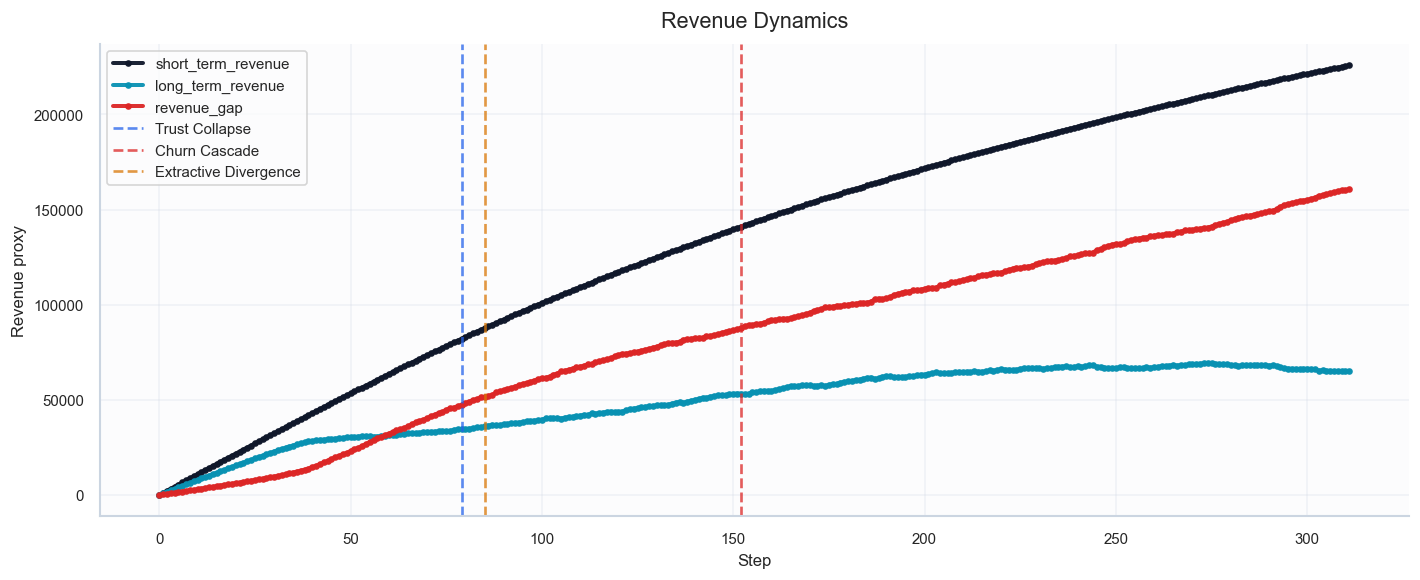

In [70]:
line_chart(
    df,
    ["short_term_revenue", "long_term_revenue", "revenue_gap"],
    "Revenue Dynamics",
    "Revenue proxy",
    colors=["#0f172a", "#0891b2", "#dc2626"],
)


## Plot 3b: Per-Step Platform Economics

This figure shows per-step revenue, costs, and profit. Revenue is discounted by the platform's reputation factor, so it declines as reputation collapses. When costs exceed revenue, per-step profit goes negative — the platform is actively losing money each step.

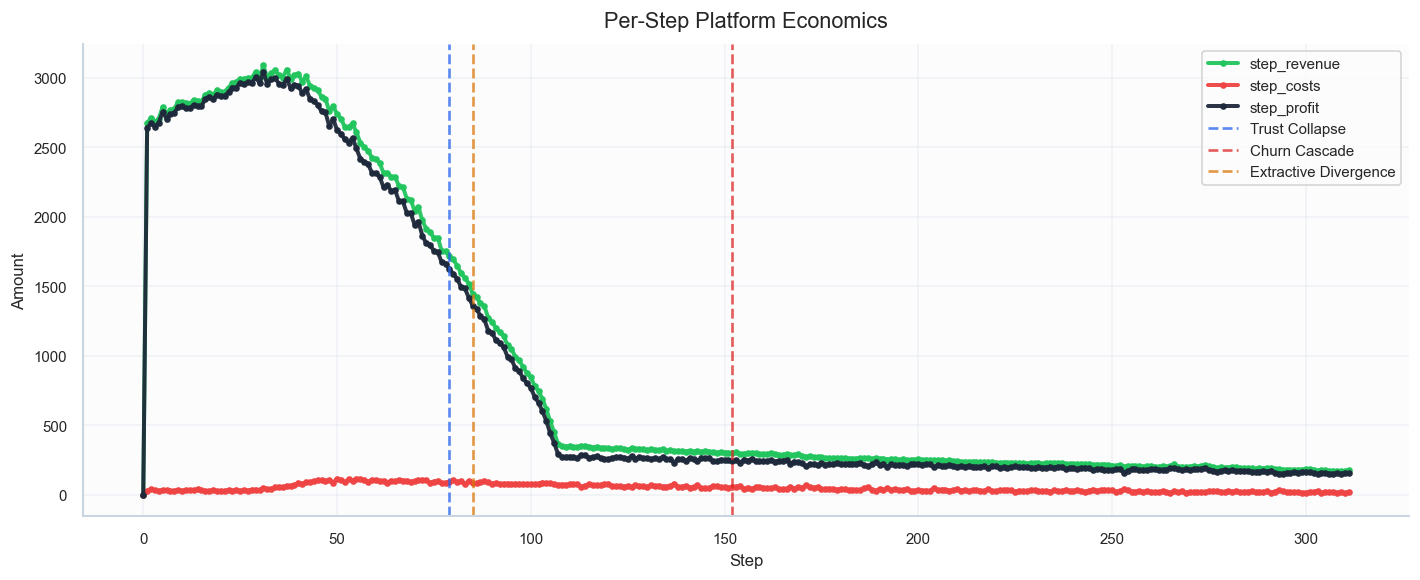

In [71]:
line_chart(
    df,
    ["step_revenue", "step_costs", "step_profit"],
    "Per-Step Platform Economics",
    "Amount",
    colors=["#22c55e", "#ef4444", "#1e293b"],
)

## Plot 3c: Cumulative Platform Economics

Running totals of revenue, costs, and net value. Cumulative revenue starts from the platform's initial traction (10,000). The gap between cumulative revenue and costs is the net value — when costs grow faster than revenue, net value flattens or declines.

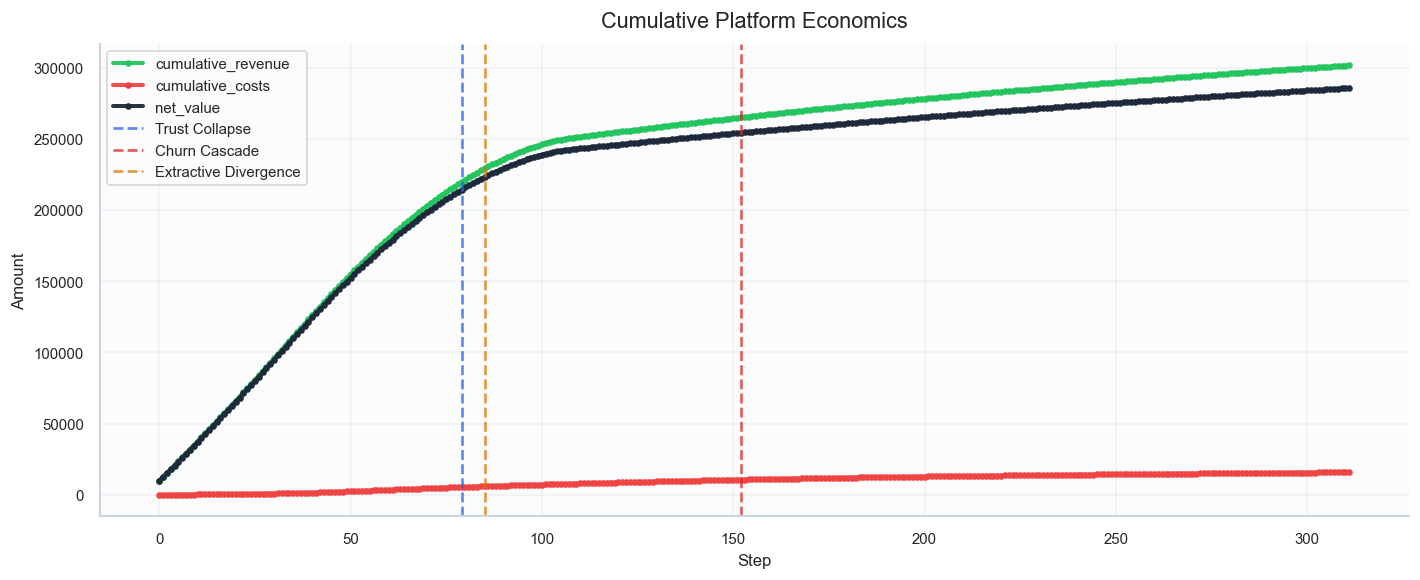

In [72]:
line_chart(
    df,
    ["cumulative_revenue", "cumulative_costs", "net_value"],
    "Cumulative Platform Economics",
    "Amount",
    colors=["#22c55e", "#ef4444", "#1e293b"],
)

## Plot 3d: Cost of Dark Patterns

This is the key counterfactual plot. It compares what the platform would have earned without dark patterns (all users retained, full initial reputation) against what it actually earned. The opportunity cost line shows the cumulative price of the dark pattern strategy — growing over time as the gap widens.

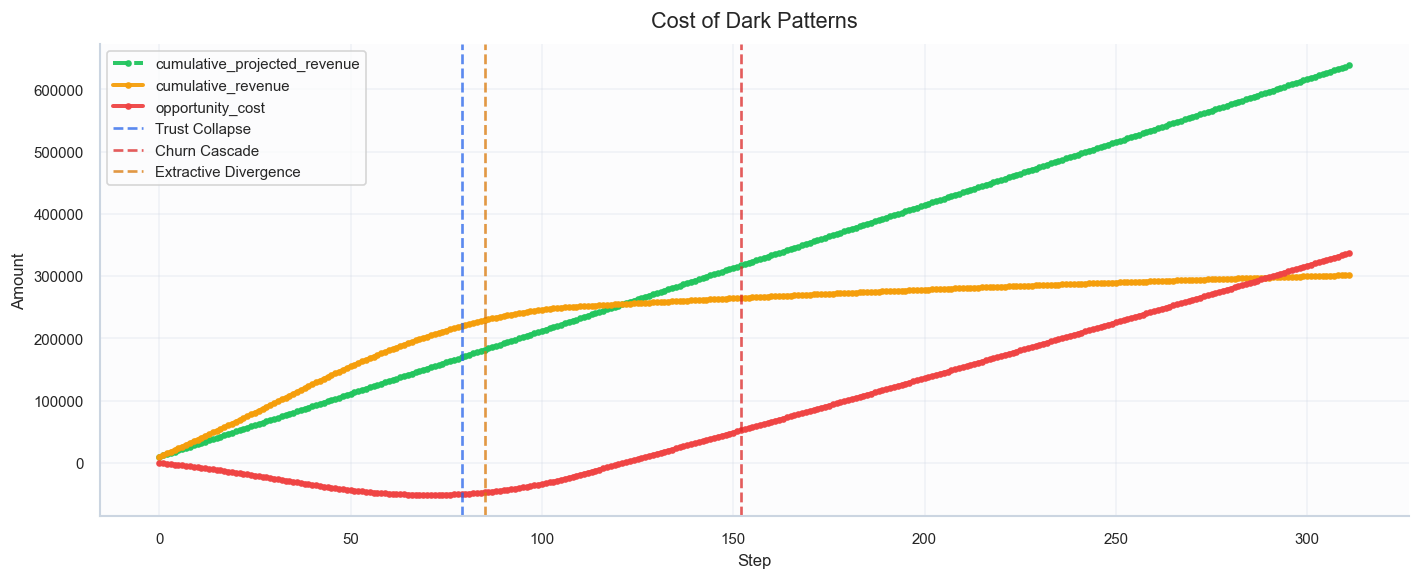

In [73]:
line_chart(
    df,
    ["cumulative_projected_revenue", "cumulative_revenue", "opportunity_cost"],
    "Cost of Dark Patterns",
    "Amount",
    colors=["#22c55e", "#f59e0b", "#ef4444"],
    styles=["--", "-", "-"],
)

## Plot 4: Active Users And Mean Harm

This figure compares engagement and accumulated harm. It helps answer whether the platform is maintaining participation while silently accumulating user damage, or whether harm is already converting into visible exit.


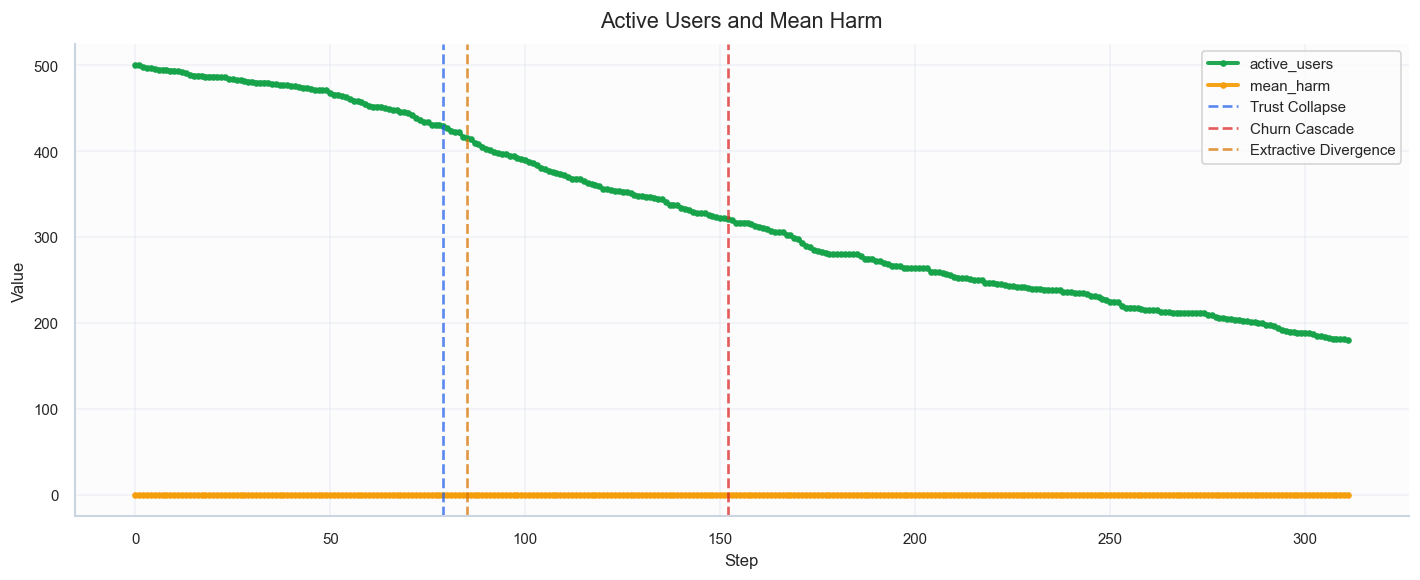

In [74]:
line_chart(
    df,
    ["active_users", "mean_harm"],
    "Active Users and Mean Harm",
    "Value",
    colors=["#16a34a", "#f59e0b"],
)


## Plot 5: Normalized System Trajectories

This plot rescales several core metrics to a common 0-1 range. It is useful when the raw metrics have different units and you want to compare shape, timing, and turning points rather than absolute magnitude.


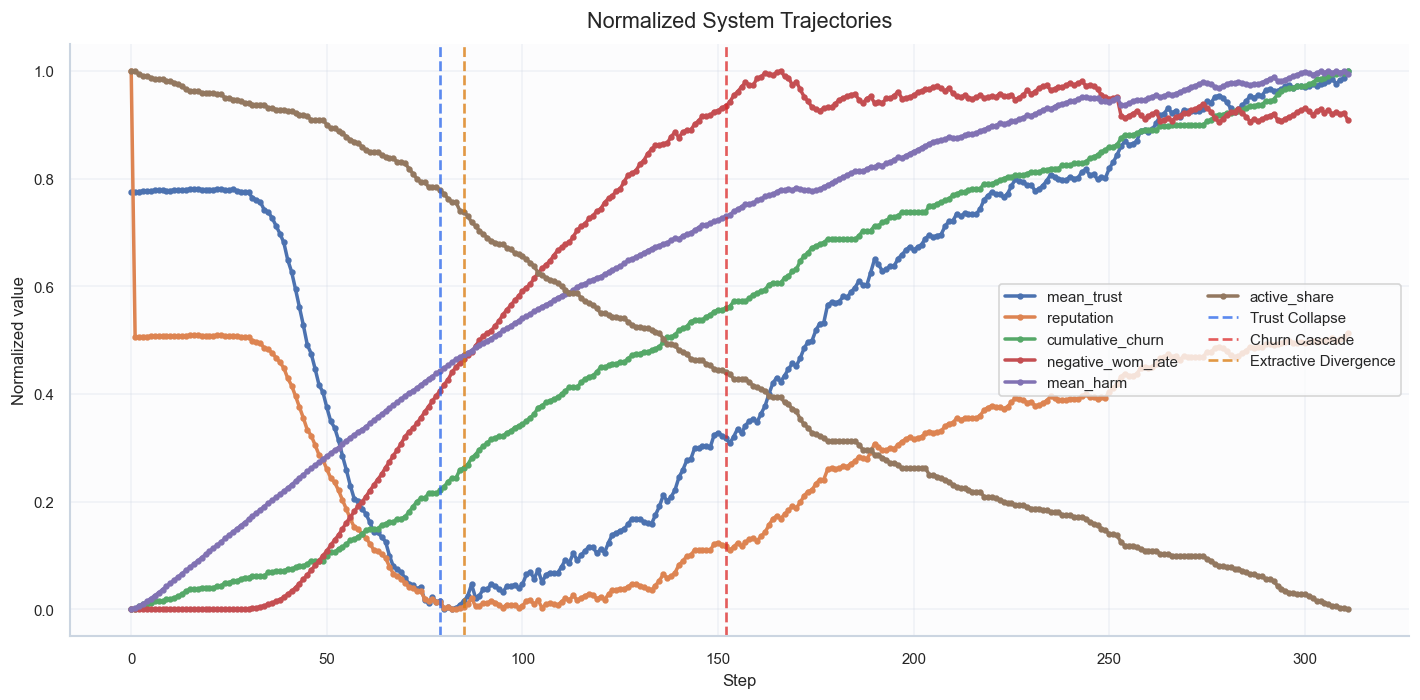

In [75]:
columns = [
    "mean_trust",
    "reputation",
    "cumulative_churn",
    "negative_wom_rate",
    "mean_harm",
    "active_share",
]
available = [column for column in columns if column in df.columns]

normalized = df[available].copy()
for column in available:
    col_min = normalized[column].min()
    col_max = normalized[column].max()
    if col_max == col_min:
        normalized[column] = 0.0
    else:
        normalized[column] = (normalized[column] - col_min) / (col_max - col_min)
normalized["step"] = df["step"]

fig, ax = plt.subplots(figsize=(12, 6))
for column in available:
    ax.plot(normalized["step"], normalized[column], linewidth=2.1, label=column, marker="o", markersize=2.8)
add_tipping_markers(df, ax)
finish_axis(ax, xlabel="Step", ylabel="Normalized value", title="Normalized System Trajectories")
ax.legend(ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


## Plot 6: Correlation Heatmap

This is an exploratory diagnostic. It does not prove causation, but it helps show which metrics move together inside the run and whether trust loss, churn, harm, reputation, and revenue separation appear tightly linked.


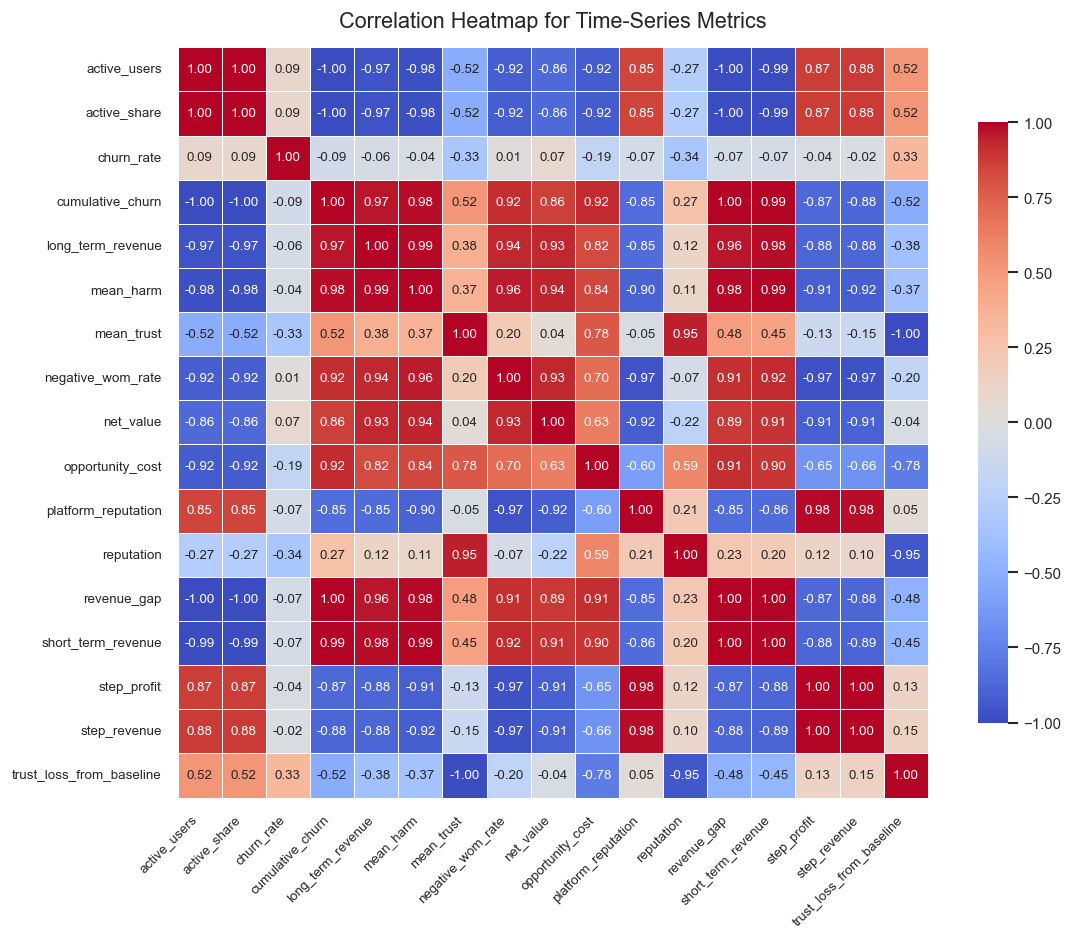

In [76]:
columns = [column for column in CORRELATION_COLUMNS if column in df.columns]
columns = [column for column in columns if df[column].nunique(dropna=True) > 1]

corr = df[columns].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 8},
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap for Time-Series Metrics", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


## Plot 7: Step-To-Step Change Diagnostics

This plot focuses on deltas rather than levels. It is useful for identifying moments of acceleration or reversal, such as sudden increases in churn or abrupt drops in trust.


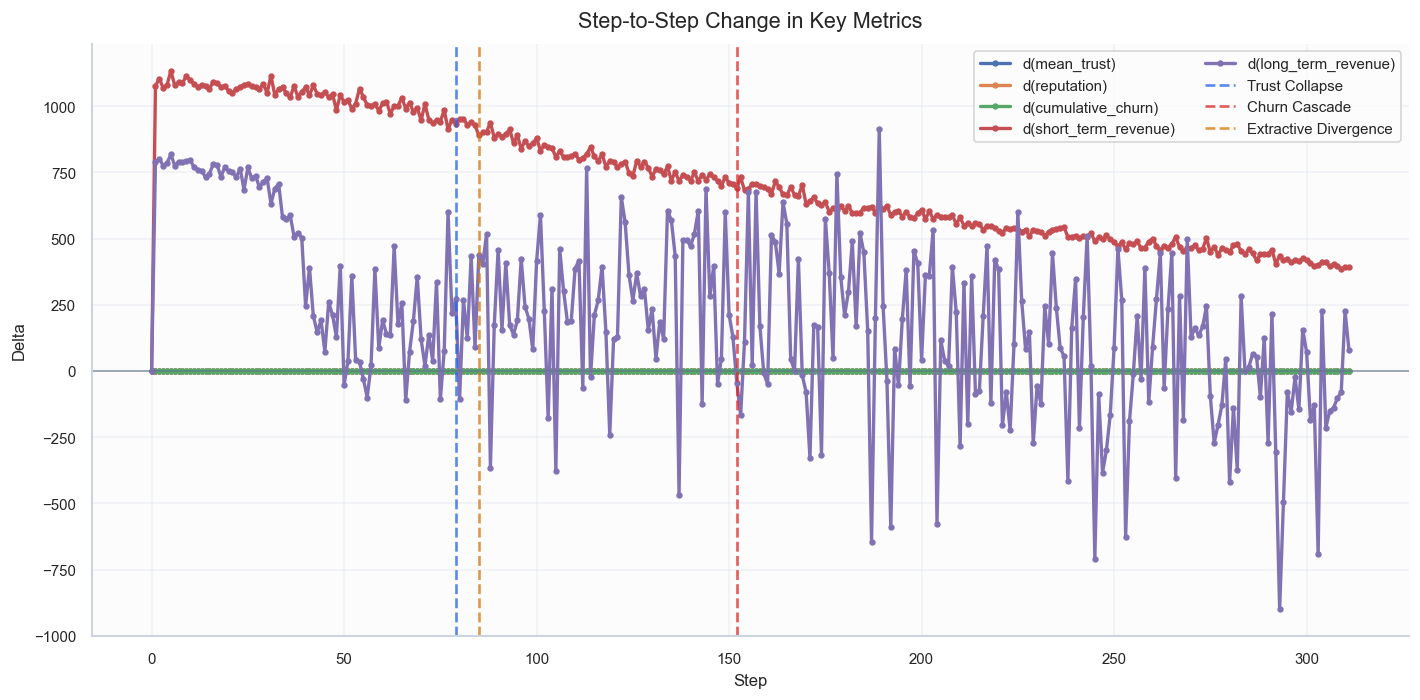

In [77]:
delta_columns = [
    column
    for column in [
        "mean_trust",
        "reputation",
        "cumulative_churn",
        "short_term_revenue",
        "long_term_revenue",
    ]
    if column in df.columns
]

delta_df = df[["step", *delta_columns]].copy()
for column in delta_columns:
    delta_df[column] = delta_df[column].diff().fillna(0.0)

fig, ax = plt.subplots(figsize=(12, 6))
for column in delta_columns:
    ax.plot(delta_df["step"], delta_df[column], linewidth=2.0, label=f"d({column})", marker="o", markersize=2.8)
ax.axhline(0, color="#64748b", linewidth=1, alpha=0.7)
add_tipping_markers(df, ax)
finish_axis(ax, xlabel="Step", ylabel="Delta", title="Step-to-Step Change in Key Metrics")
ax.legend(ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()
